PROGETTO SISTEMI COMPLESSI!!! Pinat Nicola

importazioni pacchetti e librerie

In [2]:
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt
import numpy as np
from scipy.signal import find_peaks
import matplotlib.pyplot as plt

# libreria per grafici 3D
import plotly.graph_objects as go

#libreria utile per coefficienti di lyapunov
from jitcode import jitcode_lyap, y, t

Implementazioni del sistema di ODE del paper

parametri e funzioni del primo sistema direttamente dal paper

In [3]:
#   carrying capacity di X
k0 = 3
k1 = 4

#   parametri del sistema adimensionalizzato
a1 = 4
a2 = 0.2
a3 = 0.8
a4 = 3
a5 = 2
a6 = 0.15
a7 = 0.8
a8 = 0.5
a9 = 1.5
a10 = 0.2


### Modello
Il sistema di equazioni differenziali è definito come segue:

$$
\begin{cases}
\displaystyle \frac{dx}{dt} = \frac{r_0(k_0 - x)x}{k_1 - x} - \frac{a_1 xy}{a_2 y + a_3 x + 1} = x f(x, y, z) \\
\displaystyle \frac{dy}{dt} = \frac{a_4 xy}{a_2 y + a_3 x + 1} - \frac{a_5 yz}{a_6 z + a_7 y + a_8} - y = y g(x, y, z) \\
\displaystyle \frac{dz}{dt} = \frac{a_9 yz}{a_6 z + a_7 y + a_8} - a_{10} z = z h(x, y, z)
\end{cases}
$$

La funzione è parametrica, sia per solve_ivp che per la variazione dei parametri

In [4]:
def beddingtonAngelis(t, y, r, k0, k1):
    X, Y, Z = y

    dX_dt = (r * (k0 - X) * X) / (k1 - X) - (a1 * X * Y) / (a2 * Y + a3 * X + 1) 
    dY_dt = (a4 * X * Y) / (a2 * Y + a3 * X + 1) - (a5 * Y * Z) / (a6 * Z + a7 * Y + a8) - Y 
    dZ_dt = (a9 * Y * Z) / (a6 * Z + a7 * Y + a8) - (a10 * Z)

    return [dX_dt, dY_dt, dZ_dt]

condizioni iniziali e simulazione,
variazione di r0 per vedere dove si viene a creare il caos
 

2 < r0 < 9

In [5]:
X0 = 0.1
Y0 = 0.1
Z0 = 0.1

y0 = [X0, Y0, Z0]

# simuliamo per 100 unità, analizzando le ultime 400
#t_span = (0,1000)
#t_eval = np.linspace(600, 1000, 1000)

t_span = (0,2000)
t_eval = np.linspace(1600, 2000, 2000)

In [6]:
r_plotz = []
r_ploty = []
z_plot = []
y_plot = []

print("Simulazione in corso...")
r_values = np.linspace(2,9,300)

for r in r_values:
    #   Condizioni iniziali fisse come da paper
    y_init = [0.1, 0.1, 0.1]
    
    sol = solve_ivp(beddingtonAngelis, t_span, y_init, args=(r, k0, k1), t_eval=t_eval, method='RK45', rtol=1e-6, atol=1e-8)
    
    z_values = sol.y[2]
    y_values = sol.y[1]
    
    #   find_peaks trova i massimi locali per il diagramma di biforcazioni
    peaksz, _ = find_peaks(z_values)
    peaksy, _ = find_peaks(y_values, prominence=5e-3)
        
    if len(peaksz) > 0 and len(peaksy) > 0:
        #   Prendiamo i picchi unici 
        for p in peaksz[-30:]: 
            r_plotz.append(r)
            z_plot.append(z_values[p])
        for p in peaksy[-30:]:
            r_ploty.append(r)
            y_plot.append(y_values[p])
            

Simulazione in corso...


Plot del grafico di biforcazione, è stata creata una funzioncina per rendere modulabile nel progetto

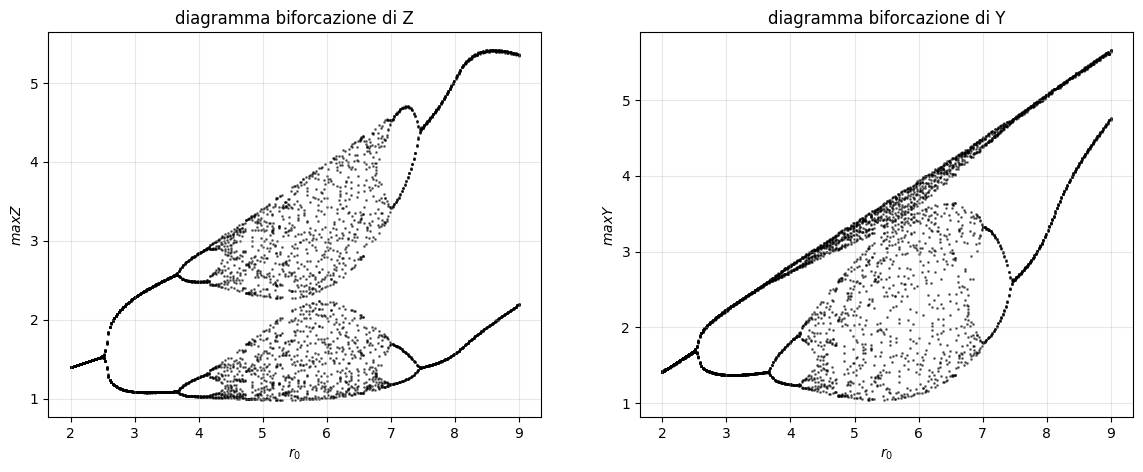

In [ ]:
def plotresults(r_ploty, r_plotz, y_plot, z_plot, parameter):
    fig, (ax1, ax2) = plt.subplots(1,2, figsize = (14,5))
    # Grafico biforcazione di Z
    
    ax1.scatter(r_plotz, z_plot, s = 1, c = "black", alpha = 0.5)
    ax1.set_title("diagramma biforcazione di Z")
    ax1.set_xlabel('$r_0$')
    ax1.set_ylabel('$maxZ$')
    ax1.grid(alpha=0.3)

    # Grafico biforcazione di Y
    ax2.scatter(r_ploty, y_plot, s = 1, c = "black", alpha = 0.5)
    ax2.set_title("diagramma biforcazione di Y")
    ax2.set_xlabel(f'${parameter}$')
    ax2.set_ylabel('$maxY$')
    ax2.grid(alpha=0.3)

plotresults(r_ploty, r_plotz, y_plot, z_plot)

Simulazione con 2 < r0 < 6

In [8]:
r_plotz = []
r_ploty = []
z_plot = []
y_plot = []

print("Simulazione in corso...")

# variazione di r_values
r_values = np.linspace(2,6,300)

for r in r_values:
    # Condizioni iniziali fisse come da paper
    y_init = [0.1, 0.1, 0.1]
    
    # Usiamo RK45
    sol = solve_ivp(
        beddingtonAngelis, t_span, y_init, args=(r,  k0, k1), 
        t_eval=t_eval, method='RK45', rtol=1e-6, atol=1e-8)
    
    z_values = sol.y[2]
    y_values = sol.y[1]
    # find_peaks trova i massimi locali per il diagramma
    peaksz, _ = find_peaks(z_values)

    # aggiungiamo dista
    peaksy, _ = find_peaks(y_values, prominence=5e-3)
        
    if len(peaksz) > 0 and len(peaksy) > 0:
        # Prendiamo i picchi unici per evitare sovrapposizioni inutili
        for p in peaksz[-30:]: 
            r_plotz.append(r)
            z_plot.append(z_values[p])
        for p in peaksy[-30:]:
            r_ploty.append(r)
            y_plot.append(y_values[p])
            

Simulazione in corso...


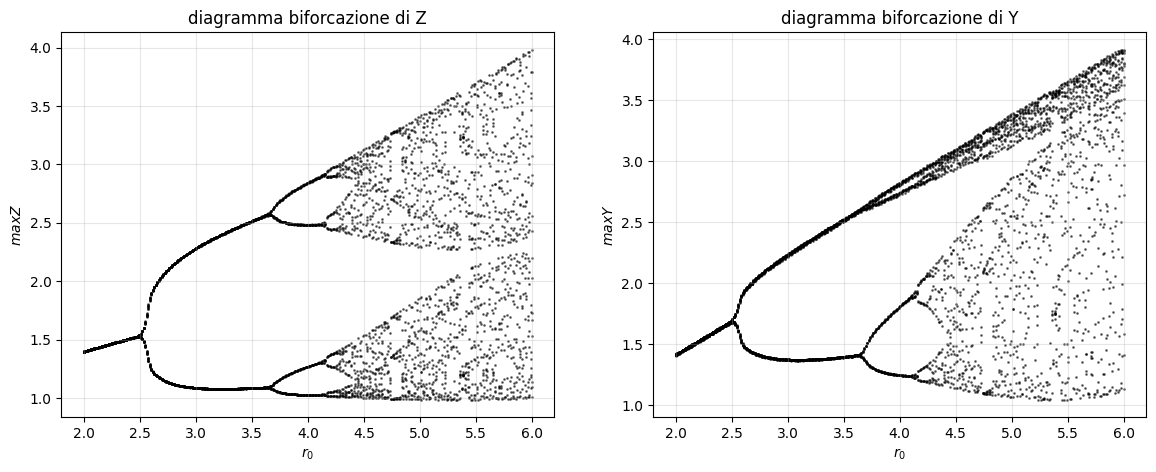

In [9]:
plotresults(r_ploty, r_plotz, y_plot, z_plot)

Facciamo variare il parametro diversamente
6 < r0 < 9

In [10]:
r_plotz = []
r_ploty = []
z_plot = []
y_plot = []

print("Simulazione in corso...")

# variazione di r_values
r_values = np.linspace(6,9,300)

for r in r_values:
    # Condizioni iniziali fisse come da paper
    y_init = [0.1, 0.1, 0.1]
    
    # Usiamo RK45
    sol = solve_ivp(
        beddingtonAngelis, t_span, y_init, args=(r,k0, k1), 
        t_eval=t_eval, method='RK45', rtol=1e-6, atol=1e-8)
    
    z_values = sol.y[2]
    y_values = sol.y[1]
    # find_peaks trova i massimi locali per il diagramma
    peaksz, _ = find_peaks(z_values)

    # aggiungiamo distanza
    peaksy, _ = find_peaks(y_values, prominence=5e-3)
        
    if len(peaksz) > 0 and len(peaksy) > 0:
        # Prendiamo i picchi unici per evitare sovrapposizioni inutili
        for p in peaksz[-30:]: 
            r_plotz.append(r)
            z_plot.append(z_values[p])
        for p in peaksy[-30:]:
            r_ploty.append(r)
            y_plot.append(y_values[p])
            

Simulazione in corso...


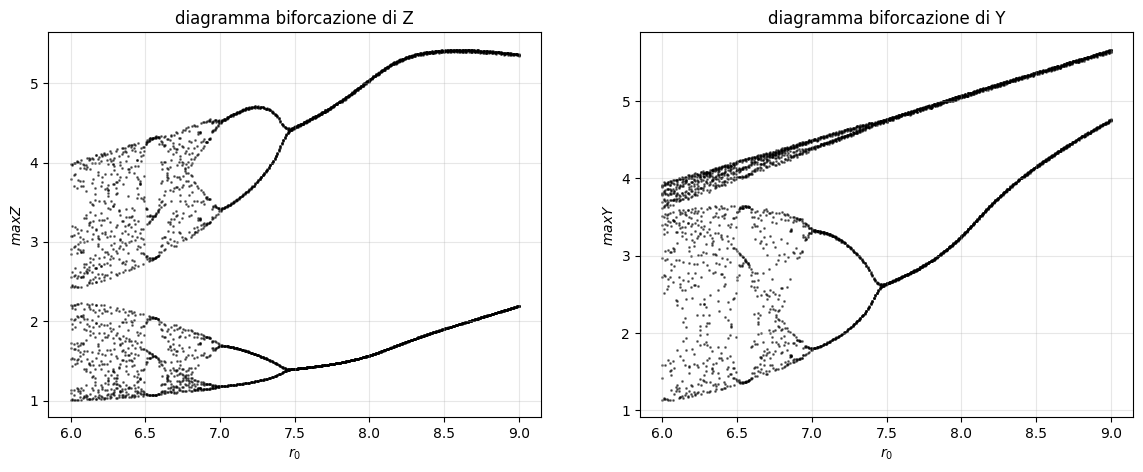

In [11]:
plotresults(r_ploty, r_plotz, y_plot, z_plot)

### VISUALIZZAZIONE DEGLI ATTRATTORI

In [12]:
x_plot = []
y_plot = []
z_plot = []

# condizioni iniziali della simulazione
X0 = 0.1
Y0 = 0.1
Z0 = 0.1

y0 = [X0, Y0, Z0]

# simuliamo per 2000 unità di tempo, analizzando le ultime 400

t_span = (0,3000)
t_eval = np.linspace(2500, 3000, 3000)


Anche in questo caso, visualizziamo gli attrattori scegliendo ogni volta un parametro diverso per vedere l'evoluzione del sistema, come si nota l'attrattore diventa sempre più "strano"

In [13]:
parametri = [2.1, 3, 3.9, 4.2, 4.5]
y_init = [X0, Y0, Z0]

for parametro in parametri:
    
    sol = solve_ivp(
    beddingtonAngelis, t_span, y_init, args=(parametro, k0, k1), 
    t_eval=t_eval, method='RK45', rtol=1e-6, atol=1e-8)

    # estraiamo le soluzioni dal sistema
    x_values = sol.y[0]
    y_values = sol.y[1]
    z_values = sol.y[2]
    
    #plottiamo il tutto
    fig = go.Figure(data=[go.Scatter3d(x=x_values, y=y_values, z=z_values, mode='lines')])
    
    fig.update_layout(title=f"Sistema di Beddington-Angelis parametro r0 = {parametro}",
               template = "plotly_white")

    fig.show()

In [14]:
parametri = [4.7, 4.75]
y_init = [X0, Y0, Z0]

t_span = (0,3000)
t_eval = np.linspace(2500, 3000, 3000)

for parametro in parametri:
    
    sol = solve_ivp(
    beddingtonAngelis, t_span, y_init, args=(parametro, k0, k1), 
    t_eval=t_eval, method='DOP853', rtol=1e-7, atol=1e-8, max_step = 0.1)

    # estraiamo le soluzioni dal sistema
    x_values = sol.y[0]
    y_values = sol.y[1]
    z_values = sol.y[2]
    
    #plottiamo il tutto
    fig = go.Figure(data=[go.Scatter3d(x=x_values, y=y_values, z=z_values, mode='lines')])
    
    fig.update_layout(title=f"Sistema di Beddington-Angelis parametro r0 = {parametro}", template = "plotly_white")
    
    fig.show()

### DAL CHAOS ALLA NORMALITA


In [15]:
parametri = [6.7, 7, 7.4, 8]
y_init = [X0, Y0, Z0]

t_span = (0,3000)
t_eval = np.linspace(2500, 3000, 3000)

for parametro in parametri:
    
    sol = solve_ivp(
    beddingtonAngelis, t_span, y_init, args=(parametro, k0, k1), 
    t_eval=t_eval, method='RK45', rtol=1e-9, atol=1e-10)

    # estraiamo le soluzioni dal sistema
    x_values = sol.y[0]
    y_values = sol.y[1]
    z_values = sol.y[2]
    
    #plottiamo il tutto
    fig = go.Figure(data=[go.Scatter3d(x=x_values, y=y_values, z=z_values, mode='lines')])
    
    fig.update_layout(title=f"Sistema di Beddington-Angelis parametro r0 = {parametro}",
               template = "plotly_white")
    
    fig.show()

### ULTERIORI SIMULAZIONI CON VARIAZIONE DI PARAMETRI

In [16]:
# carrying capacity di X
k1 = 4

In [17]:
k0_plotz = []
k0_ploty = []
z_plot = []
y_plot = []

print("Simulazione in corso...")
K0_values = np.linspace(1.7,4,300)

for k0 in K0_values[:-1]:
    # Condizioni iniziali fisse come da paper
    y_init = [0.1, 0.1, 0.1]
    
    # Usiamo RK45
    sol = solve_ivp(beddingtonAngelis, t_span, y_init, args=(5, k0, k1), t_eval=t_eval, method='RK45', rtol=1e-6, atol=1e-8)
    
    z_values = sol.y[2]
    y_values = sol.y[1]
    # find_peaks trova i massimi locali per il diagramma
    peaksz, _ = find_peaks(z_values)

    # aggiungiamo distanza
    peaksy, _ = find_peaks(y_values, prominence=5e-3)
        
    if len(peaksz) > 0 and len(peaksy) > 0:
        # Prendiamo i picchi unici per evitare sovrapposizioni inutili
        for p in peaksz[-30:]: 
            k0_plotz.append(k0)
            z_plot.append(z_values[p])
        for p in peaksy[-30:]:
            k0_ploty.append(k0)
            y_plot.append(y_values[p])
            

Simulazione in corso...


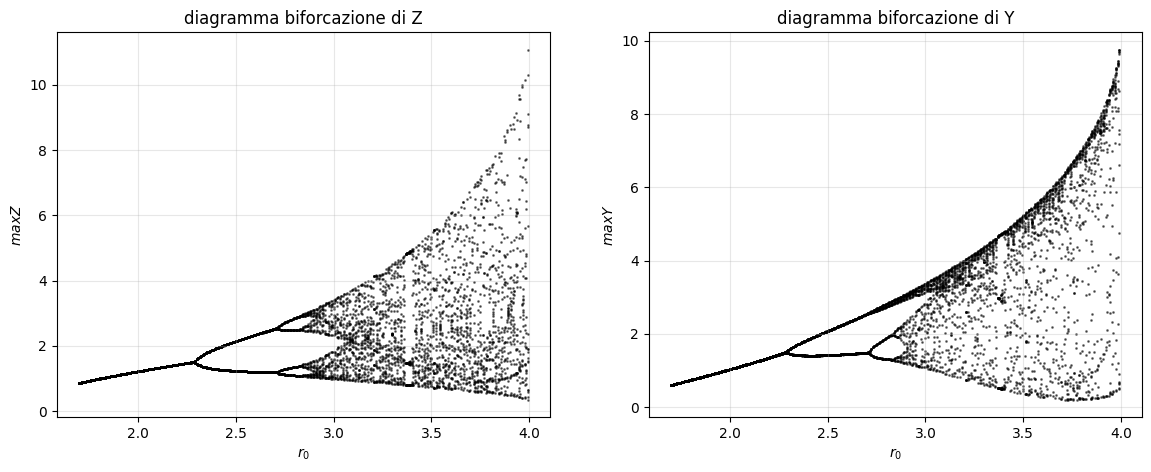

In [18]:
plotresults(k0_ploty, k0_plotz, y_plot, z_plot)

Simulazioni per z, nel caso di 1.7 < k0 < 3.3  e per 3.3 < k0 < 4

In [19]:
k0_plotz = []
k0_ploty = []
z_plot = []
y_plot = []

print("Simulazione in corso...")
K0_values = np.linspace(1.7,3.3,300)

for k0 in K0_values[:-1]:
    # Condizioni iniziali fisse come da paper
    y_init = [0.1, 0.1, 0.1]
    
    # Usiamo RK45
    sol = solve_ivp(
        beddingtonAngelis, t_span, y_init, args=(5, k0, k1), 
        t_eval=t_eval, method='RK45', rtol=1e-6, atol=1e-8)
    
    z_values = sol.y[2]
    y_values = sol.y[1]
    # find_peaks trova i massimi locali per il diagramma
    peaksz, _ = find_peaks(z_values)

    # aggiungiamo distanza
    peaksy, _ = find_peaks(y_values, prominence=5e-3)
        
    if len(peaksz) > 0 and len(peaksy) > 0:
        # Prendiamo i picchi unici per evitare sovrapposizioni inutili
        for p in peaksz[-30:]: 
            k0_plotz.append(k0)
            z_plot.append(z_values[p])
        for p in peaksy[-30:]:
            k0_ploty.append(k0)
            y_plot.append(y_values[p])
            

Simulazione in corso...


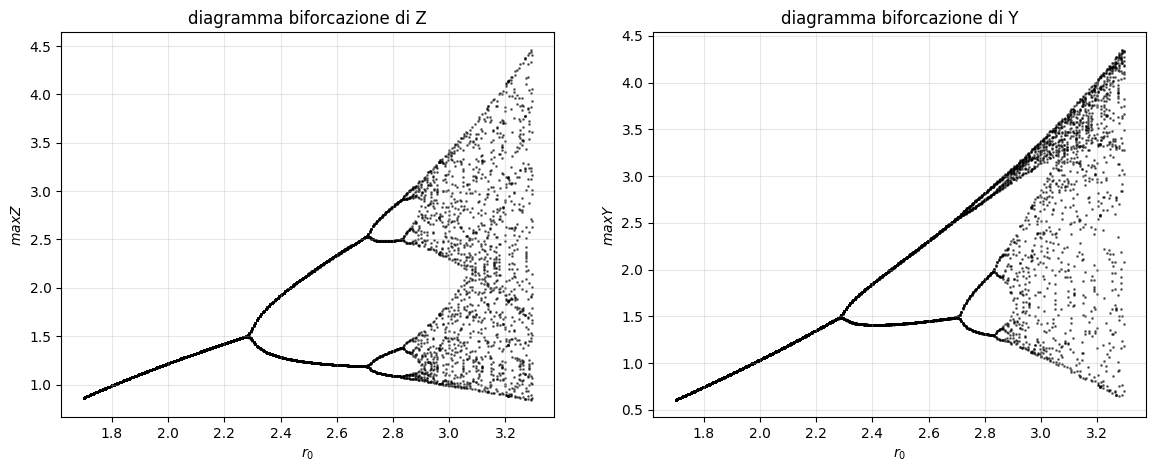

In [20]:
plotresults(k0_ploty, k0_plotz, y_plot, z_plot)

In questa sezione la simulazione può risultare pesante, è stato quindi usato un check sulla soluzione ritornata da solve_ivp per evitare errori numerici, l'output mostra quali soluzioni sono state saltate per consentire una corretta simulazione

In [ ]:
k0_plotz = []
k0_ploty = []
z_plot = []
y_plot = []

print("Simulazione in corso...")
K0_values = np.linspace(3.3,4,300)

t_span = (0,2000)
t_eval = np.linspace(1500, 2000, 2000)


for k0 in K0_values[:-1]:
    # Condizioni iniziali fisse come da paper
    y_init = [0.1, 0.1, 0.1]
    
    # Usiamo DOP853 in quanto simulazioni troppo longhe altrimenti
    # abbassiamo anche la tolleranza sempre per lo stesso motivo
    sol = solve_ivp(beddingtonAngelis, t_span, y_init, args=(5, k0, k1),  t_eval=t_eval, method='DOP853', rtol=1e-5, atol=1e-7)
    
    
    # aggiunto un check per la soluzione di solve
    if (not sol.success) or (sol.y is None) or (len(sol.y) < 3) or (len(sol.y[0]) == 0):
        print(f"skip k0={k0:.5f} | {sol.message}")
        continue

    z_values = sol.y[2]
    peaksz, _ = find_peaks(z_values)

    # aggiungiamo distanza
    # peaksy, _ = find_peaks(y_values, prominence=5e-3)
        
    for p in peaksz[-30:]: 
        k0_plotz.append(k0)
        z_plot.append(z_values[p])

Simulazione in corso...


C:\Users\pinat\AppData\Local\Temp\ipykernel_23252\3535256792.py:4: RuntimeWarning:

overflow encountered in scalar multiply

C:\Users\pinat\AppData\Local\Temp\ipykernel_23252\3535256792.py:4: RuntimeWarning:

invalid value encountered in scalar divide

C:\Users\pinat\AppData\Local\Temp\ipykernel_23252\3535256792.py:5: RuntimeWarning:

invalid value encountered in scalar divide

c:\Users\pinat\AppData\Local\Programs\Python\Python313\Lib\site-packages\scipy\integrate\_ivp\rk.py:66: RuntimeWarning:

invalid value encountered in dot

c:\Users\pinat\AppData\Local\Programs\Python\Python313\Lib\site-packages\scipy\integrate\_ivp\rk.py:521: RuntimeWarning:

invalid value encountered in dot

c:\Users\pinat\AppData\Local\Programs\Python\Python313\Lib\site-packages\scipy\integrate\_ivp\rk.py:522: RuntimeWarning:

invalid value encountered in dot

c:\Users\pinat\AppData\Local\Programs\Python\Python313\Lib\site-packages\scipy\integrate\_ivp\rk.py:63: RuntimeWarning:

invalid value encountered in do

skip k0=3.74716 | Required step size is less than spacing between numbers.
skip k0=3.80569 | Required step size is less than spacing between numbers.
skip k0=3.81271 | Required step size is less than spacing between numbers.
skip k0=3.82910 | Required step size is less than spacing between numbers.
skip k0=3.85485 | Required step size is less than spacing between numbers.
skip k0=3.87124 | Required step size is less than spacing between numbers.
skip k0=3.87826 | Required step size is less than spacing between numbers.
skip k0=3.89231 | Required step size is less than spacing between numbers.
skip k0=3.91572 | Required step size is less than spacing between numbers.
skip k0=3.92977 | Required step size is less than spacing between numbers.
skip k0=3.93913 | Required step size is less than spacing between numbers.
skip k0=3.94147 | Required step size is less than spacing between numbers.
skip k0=3.94381 | Required step size is less than spacing between numbers.
skip k0=3.94615 | Require

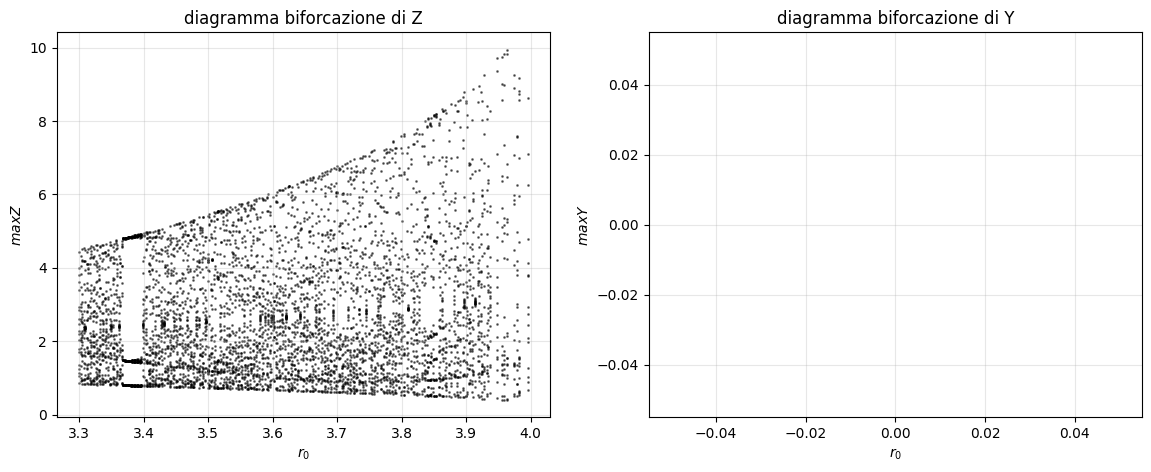

In [22]:
plotresults(k0_ploty, k0_plotz, y_plot, z_plot)

Diagrammi di biforcazione per 4 < k1 < 10

In [23]:
k0_plotz = []
k0_ploty = []
z_plot = []
y_plot = []

print("Simulazione in corso...")
K1_values = np.linspace(4.1,10,300)

for k1 in K1_values[:-1]:
    # Condizioni iniziali fisse come da paper
    y_init = [0.1, 0.1, 0.1]
    
    # Usiamo RK45
    sol = solve_ivp(beddingtonAngelis, t_span, y_init, args=(5, k0, k1), t_eval=t_eval, method='RK45', rtol=1e-6, atol=1e-8)
    
    z_values = sol.y[2]
    y_values = sol.y[1]
    # find_peaks trova i massimi locali per il diagramma
    peaksz, _ = find_peaks(z_values)

    # aggiungiamo distanza
    peaksy, _ = find_peaks(y_values, prominence=5e-3)
        
    if len(peaksz) > 0 and len(peaksy) > 0:
        # Prendiamo i picchi unici per evitare sovrapposizioni inutili
        for p in peaksz[-30:]: 
            k0_plotz.append(k1)
            z_plot.append(z_values[p])
        for p in peaksy[-30:]:
            k0_ploty.append(k1)
            y_plot.append(y_values[p])

Simulazione in corso...


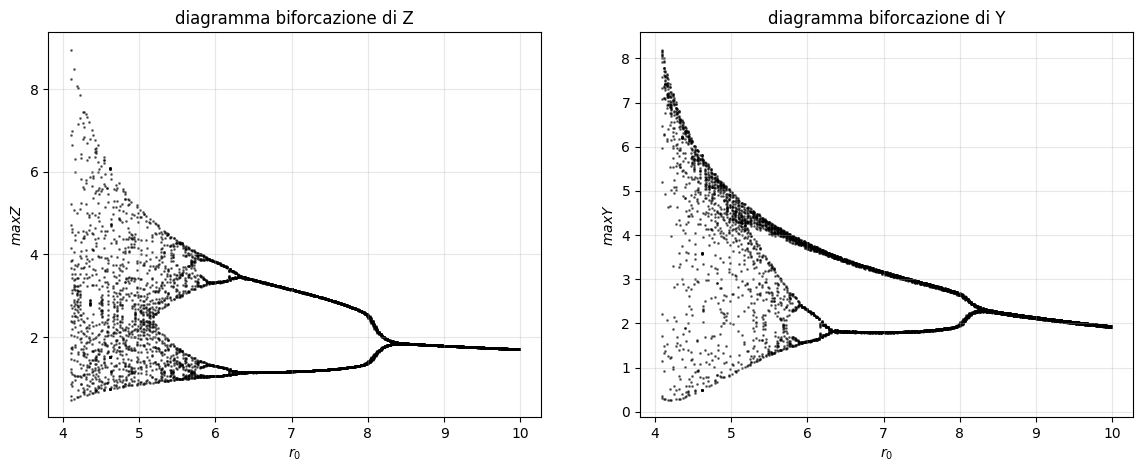

In [24]:
plotresults(k0_ploty, k0_plotz, y_plot, z_plot)

## Attrattori al variare di k0

In [37]:
parametri = [2, 2.5, 2.8, 2.85, 2.9]
y_init = [X0, Y0, Z0]
r0 = 5
k1 = 4

for parametro in parametri:
    
    sol = solve_ivp(
    beddingtonAngelis, t_span, y_init, args=(r0, parametro, k1), 
    t_eval=t_eval, method='RK45', rtol=1e-8, atol=1e-9)

    # estraiamo le soluzioni dal sistema
    x_values = sol.y[0]
    y_values = sol.y[1]
    z_values = sol.y[2]
    
    #plottiamo il tutto
    fig = go.Figure(data=[go.Scatter3d(x=x_values, y=y_values, z=z_values, mode='lines')])
    
    fig.update_layout(title=f"Sistema di Beddington-Angelis parametro k0 = {parametro}", template = "plotly_white")

    fig.show()

Simulazione per vedere cosa succede se cambio di poco k0 da 3.35 a un valore leggermente superiore

In [38]:
parametri = [3.35, 3.38]
y_init = [X0, Y0, Z0]

t_span = (0,3000)
t_eval = np.linspace(2500, 3000, 3000)

for parametro in parametri:
    
    sol = solve_ivp(beddingtonAngelis, t_span, y_init, args=(r0, parametro, k1),  t_eval=t_eval, method='DOP853', rtol=1e-7, atol=1e-8)

    # estraiamo le soluzioni dal sistema
    x_values = sol.y[0]
    y_values = sol.y[1]
    z_values = sol.y[2]
    
    #plottiamo il tutto
    fig = go.Figure(data=[go.Scatter3d(x=x_values, y=y_values, z=z_values, mode='lines')])
    
    fig.update_layout(title=f"Sistema di Beddington-Angelis parametro k0 = {parametro}", template = "plotly_white")
    
    fig.show()

## CALCOLO DEGLI ESPONENTI DI LYAPUNOV

Qui è stato usato jitcode e sono state fatte diverse prove per vedere come avere una simulazione ottimale, per una precisione ulteriore sarebbe da avere un timespan piu grande, ma siamo rimasti leggeri per non avere runtime di eccessivo tempo. 
In ogni caso si evidenziano le aree caratteristiche che troviamo anche nel paper, è stata fatta una simulazione per r0 e per k0, inoltre è stata fatta una funzione che ritorna il sistema, serve per jitcode

In [27]:
import numpy as np
from symengine import symbols

# Definiamo le equazioni del sistema
# y(0)=x, y(1)=y, y(2)=z

k0_plot = []
r0_plot = []
r0lyap = []
k0lyap = []

k0_sym, r0_sym = symbols("k0 r0")
k1=4

def geteuqations(k0, r0):
    f = [
        r0 * (k0 - y(0)) * y(0) / (k1 - y(0)) - (a1 * y(0) * y(1)) / (a2 * y(1) + a3 * y(0) + 1),
        (a4 * y(0) * y(1)) / (a2 * y(1) + a3 * y(0) + 1)
        - (a5 * y(1) * y(2)) / (a6 * y(2) + a7 * y(1) + a8)
        - y(1),
        (a9 * y(1) * y(2)) / (a6 * y(2) + a7 * y(1) + a8) - a10 * y(2),
    ]
    return f


r0_values = np.linspace(2, 7.04, 100)
k0_values = np.linspace(1.7, 3.30, 100)

# Compila una sola volta e varia i parametri con set_parameters
f_sym = geteuqations(k0_sym, r0_sym)
ODE_r0 = jitcode_lyap(f_sym, n_lyap=3, control_pars=[k0_sym, r0_sym])
ODE_r0.generate_f_lambda()
ODE_r0.set_integrator("dopri5")

# IMPLEMENTAZIONE PER r0
for r0 in r0_values:
    ODE_r0.set_parameters(3.0, float(r0))
    ODE_r0.set_initial_value([0.1, 0.1, 0.1], 0.0)

    # Transiente
    ODE_r0.integrate(1000.0)

    # out = (stato, esponenti_lyapunov, vettori_tangenti)
    #out = ODE_r0.integrate(2000.0)

    # Massimo esponente di Lyapunov
    
    local_lle = []
    t_now = 1000.0
    for _ in range(12):
        t_now += 100.0
        out = ODE_r0.integrate(t_now)
        local_lle.append(float(out[1][0]))

    r0lyap.append(np.mean(local_lle[6:]))   # media ultima metà
    

c:\Users\pinat\AppData\Local\Programs\Python\Python313\Lib\site-packages\jitcode\_jitcode.py:771: RuntimeWarning:

divide by zero encountered in log



In [28]:
# IMPLEMENTAZIONE PER K0

f_sym = geteuqations(k0_sym, r0_sym)
ODE_k0 = jitcode_lyap(f_sym, n_lyap=3, control_pars=[k0_sym, r0_sym])
ODE_k0.generate_f_lambda()
ODE_k0.set_integrator("dopri5", rtol = 1e-9, atol = 1e-12)

for k0 in k0_values:
    ODE_k0.set_parameters(float(k0), 5.0)
    ODE_k0.set_initial_value([0.1, 0.1, 0.1], 0.0)

    # Transiente
    ODE_k0.integrate(1000.0)

    # out = (stato, esponenti_lyapunov, vettori_tangenti)
    
    local_lle = []
    t_now = 1000.0
    for _ in range(12):
        t_now += 200.0
        out = ODE_k0.integrate(t_now)
        local_lle.append(float(out[1][0]))

    k0lyap.append(np.mean(local_lle[6:]))  # media ultima metà

### PLOTTING DEI RISULTATI

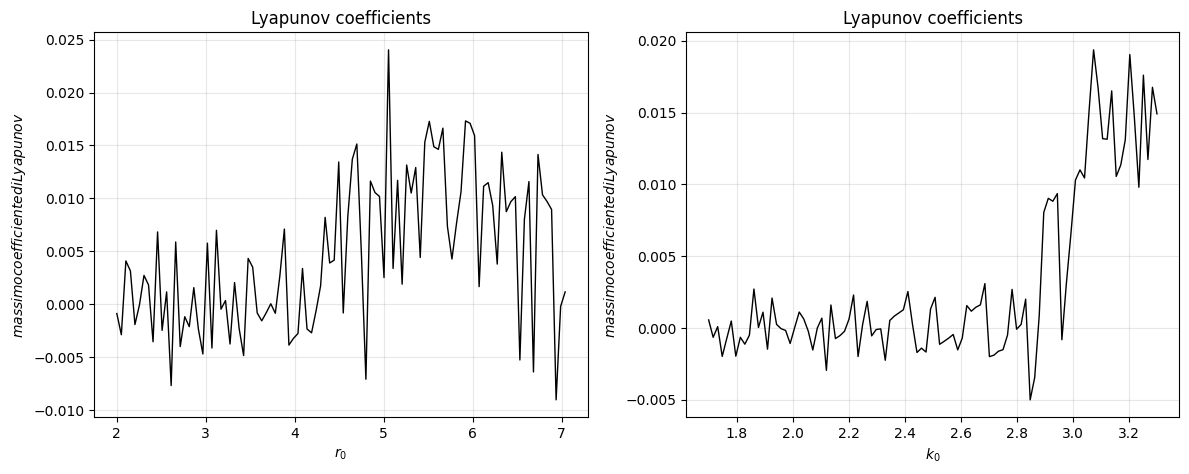

In [29]:

fig, (ax1, ax2) = plt.subplots(1,2, figsize = (14,5))

ax1.plot(r0_values, r0lyap, 'k-', lw=1, label="Massimo esponente di lyapunov")
ax1.set_title("Lyapunov coefficients")
ax1.set_xlabel('$r_0$')
ax1.set_ylabel('$massimo coefficiente di Lyapunov$')
ax1.grid(alpha=0.3)

# Grafico biforcazione di Y
ax2.plot(k0_values, k0lyap, 'k-', lw = 1, label = "Massimo esponente di Lyapunov")
ax2.set_title("Lyapunov coefficients")
ax2.set_xlabel('$k_0$')
ax2.set_ylabel('$massimo coefficiente di Lyapunov$')
ax2.grid(alpha=0.3)

## CONDIZIONI INIZIALI 

Verifichiamo quanto il sistema è sensibile alle condizioni iniziali,
in questo caso prendiamo un parametro che rende il sistema caotico ($r_0 = 3.5$) e facciamo partire la simulazione con due condizioni iniziali diverse 

$$
(X,Y,Z) = (0.1, 0.1,0.1)
$$
e
$$
(X,Y,Z) = (0.100001, 0.1, 0.1)
$$


verifichiamo che la $$\left| \Delta z(t) \right|$$
in scala logaritmica diverge esponenzialmente, se così fosse ( come ci aspettiamo ) confermermo la natura caotica del modello 

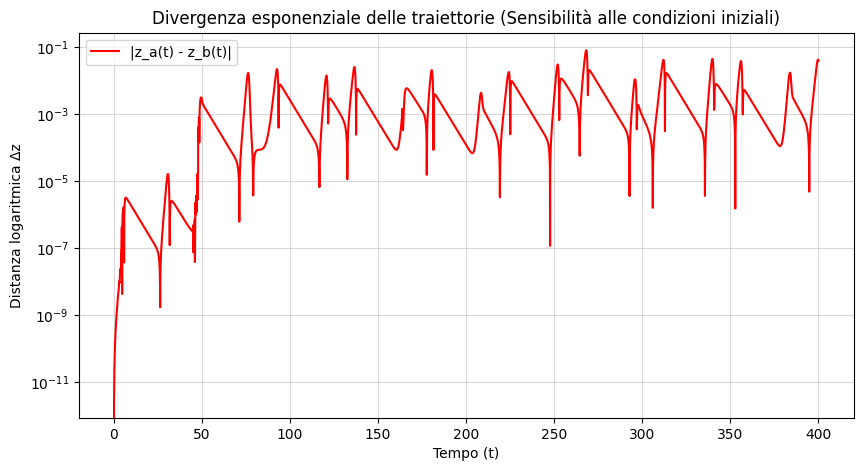

In [30]:
# parametro che porta il sistema al chaos
r0 = 3.5
k0 = 3
k1 = 4

def beddingtonDeAngelis(t, y):
    X, Y, Z = y

    dX_dt = (r0 * (k0 - X) * X) / (k1 - X) - (a1 * X * Y) / (a2 * Y + a3 * X + 1) 
    dY_dt = (a4 * X * Y) / (a2 * Y + a3 * X + 1) - (a5 * Y * Z) / (a6 * Z + a7 * Y + a8) - Y 
    dZ_dt = (a9 * Y * Z) / (a6 * Z + a7 * Y + a8) - (a10 * Z)

    return [dX_dt, dY_dt, dZ_dt]


# condizioni iniziali della simulazione
w0_a = [0.1, 0.1, 0.1]          #classica
w0_b = [0.10000001, 0.1, 0.1]   #perturbazione infinitesimale

t = np.linspace(0, 400, 4000)

# Calcoliamo le oribite e poi calcoliamo la differenza

sol_a = solve_ivp(beddingtonDeAngelis, [0, 400], w0_a, t_eval=np.linspace(0, 400, 4000))

sol_b = solve_ivp(beddingtonDeAngelis, [0, 400], w0_b, t_eval=np.linspace(0, 400, 4000))

# Calcolo differenza prendendo la z
delta_z = np.abs(sol_a.y[2] - sol_b.y[2])
n = min(sol_a.y[2].shape[0], sol_b.y[2].shape[0])
delta_z = np.abs(sol_a.y[2][:n] - sol_b.y[2][:n])
t_plot = sol_a.t[:n]

#uso della scala logarmitmica
plt.figure(figsize=(10, 5))
plt.semilogy(t_plot, delta_z, color='red', label='|z_a(t) - z_b(t)|')
plt.title('Divergenza esponenziale delle traiettorie (Sensibilità alle condizioni iniziali)')
plt.xlabel('Tempo (t)')
plt.ylabel('Distanza logaritmica Δz')
plt.grid(True, which="both", ls="-", alpha=0.5)
plt.legend()
plt.show()

Questo conferma la nauta caotica del modello, infatti la differenza fra le due orbite cresce in maniera esponenziale e poi si stabilizza ciclicamente, questo perchè ormai il sistema ( in entrambe le soluzioni ) si è stabilizzato sull'attrattore strano e avendo orbite diverse e trovandosi su un attrattore diverso, la differenza avrà un andamento ciclico

# STABILIZZAZIONE PER INTERFERENZA

Cosa succede se modifichiamo il parametro a2?

In [31]:
def beddingtonDeAngelis(t, y, a2):
    X, Y, Z = y

    dX_dt = (r0 * (k0 - X) * X) / (k1 - X) - (a1 * X * Y) / (a2 * Y + a3 * X + 1) 
    dY_dt = (a4 * X * Y) / (a2 * Y + a3 * X + 1) - (a5 * Y * Z) / (a6 * Z + a7 * Y + a8) - Y 
    dZ_dt = (a9 * Y * Z) / (a6 * Z + a7 * Y + a8) - (a10 * Z)

    return [dX_dt, dY_dt, dZ_dt]


In [ ]:
a2_values = np.linspace(0.1, 1.5, 200)
biforcazione_z = []
r0 = 4.5 # parametro che ci assicura il caos nel sistema come visto in precedenza

# iteriamo sui valorei di a2, per vedere se riusciamo a tornare alla stabilità se aumentiamo l'interferenza fra i predatori
for val_a2 in a2_values:
    sol = solve_ivp(beddingtonDeAngelis, [0, 800], y0, args = (val_a2,), t_eval=np.linspace(600, 800, 1000))
    
    # Trova i massimi locali per il diagramma
    z_vals = sol.y[2]
    maschera = (z_vals[1:-1] > z_vals[:-2]) & (z_vals[1:-1] > z_vals[2:])
    peaks = z_vals[1:-1][maschera] 
    
    for peak in peaks:
        biforcazione_z.append([val_a2, peak])



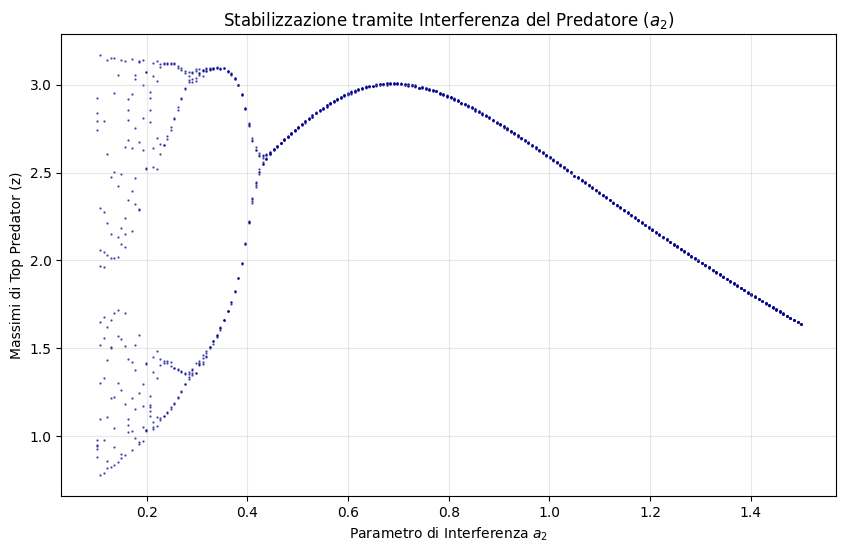

In [33]:
# Plotting
bif_data = np.array(biforcazione_z)
plt.figure(figsize=(10, 6))
plt.scatter(bif_data[:, 0], bif_data[:, 1], s=0.5, color='darkblue', alpha=0.6)
plt.title('Stabilizzazione tramite Interferenza del Predatore ($a_2$)')
plt.xlabel('Parametro di Interferenza $a_2$')
plt.ylabel('Massimi di Top Predator (z)')
plt.grid(True, alpha=0.3)
plt.show()

Mostriamo anche gli attrattori con $a_2 = 1.4$

In [34]:
sol = solve_ivp(
    beddingtonDeAngelis, t_span, y0, args=(1.4,),
    t_eval=t_eval, method='RK45', rtol=1e-6, atol=1e-8)

x_values = sol.y[0]
y_values = sol.y[1]
z_values = sol.y[2]
    
fig = go.Figure(data=[go.Scatter3d(x=x_values, y=y_values, z=z_values, mode='lines')])
    
fig.update_layout(title=f"Attrattore del modello con parametro a2 = {a2}", template = "plotly_white")

fig.show()

Conferma anche questa ulteriore del fatto che il modello si può portare ad una condizione non caotica tramite i giusti parametri, in questo caso la risposta funzionale di Beddington-DeAngelis ci aiuta